# Notebook 03 — Preprocessing + Sentiment Analysis
**Owner:** Person 3

**Input:** `../data/reddit/reddit_raw.csv` (from Notebook 02)

**Goal:** Clean Reddit text, score sentiment per post using VADER, and aggregate to a weekly sentiment index.

**Output:** `../data/processed/sentiment_weekly.csv`

**Columns:** `week | subreddit | avg_sentiment | post_count | avg_upvotes`

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import spacy
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)
nlp = spacy.load('en_core_web_sm')
vader = SentimentIntensityAnalyzer()

## 1. Load Reddit Data

In [2]:
df = pd.read_csv("../data/reddit/reddit_raw.csv", parse_dates=["date"])
print(f"Loaded {len(df)} posts")
print(df["subreddit"].value_counts())
df.head()

Loaded 3452 posts
subreddit
pcmasterrace    1897
hardware         828
buildapc         727
Name: count, dtype: int64


,post_id,date,subreddit,title,body,top_comments,upvotes,url
0,7z0a690,2025-05-18,hardware,GPU prices after the tariff announcement,NaN,My local Microcenter had these in stock all we...,86,https://www.reddit.com/r/hardware/comments/7z0...
1,xaq7nxn,2025-05-18,pcmasterrace,GPU price increase because of tariffs?,"I found a great deal at Microcenter, prices th...",Just wait - prices always drop eventually. No ...,68,https://www.reddit.com/r/pcmasterrace/comments...
2,2xqz21x,2025-05-18,pcmasterrace,Build help - what GPU should I get?,NaN,NaN,15,https://www.reddit.com/r/pcmasterrace/comments...
3,493685e,2025-05-18,pcmasterrace,Best value build right now?,NaN,Prices are definitely volatile right now. Hard...,50,https://www.reddit.com/r/pcmasterrace/comments...
4,8ykehvq,2025-05-17,pcmasterrace,RTX 4060 price dropped to $299 - worth it?,AMD seems to be keeping prices competitive wit...,DDR5 prices have finally come down to earth. N...,93,https://www.reddit.com/r/pcmasterrace/comments...


## 2. Build Full Text Field
Combine title + body + top comments for richer sentiment signal.

In [3]:
def combine_text(row) -> str:
    parts = [
        str(row.get("title", "") or ""),
        str(row.get("body", "") or ""),
        str(row.get("top_comments", "") or "")
    ]
    return " ".join(parts)
df["full_text"] = df.apply(combine_text, axis=1)
print("Sample full text:")
print(df["full_text"].iloc[0][:300])

Sample full text:
GPU prices after the tariff announcement nan My local Microcenter had these in stock all week. Prices seem stable there. | Just wait - prices always drop eventually. No rush unless you need it now. | Don't sleep on AMD right now. RX 7600 series is excellent value.


## 3. Text Preprocessing

In [4]:
STOP_WORDS = set(stopwords.words('english'))
def preprocess(text: str) -> str:
    """Lowercase, remove URLs/special chars, lemmatize, remove stopwords."""
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower().strip()
    doc = nlp(text, disable=["ner", "parser"])
    tokens = [
        token.lemma_ for token in doc
        if token.lemma_ not in STOP_WORDS and len(token.lemma_) > 2
    ]
    return " ".join(tokens)
df["text_clean"] = df["full_text"].apply(preprocess)
print("Preprocessing done")
df[["full_text", "text_clean"]].head(2)

Preprocessing done


,full_text,text_clean
0,GPU prices after the tariff announcement nan M...,gpu price tariff announcement nan local microc...
1,GPU price increase because of tariffs? I found...,gpu price increase tariff find great deal micr...


## 4. Sentiment Scoring with VADER
VADER is designed for social media text — handles slang, caps, punctuation well.

We score on raw `full_text` (not preprocessed) — VADER relies on punctuation/capitalization for signal.

In [5]:
def score_sentiment(text: str) -> float:
    """Return VADER compound score: -1 (very negative) to +1 (very positive)."""
    return vader.polarity_scores(text)["compound"]
df["sentiment_score"] = df["full_text"].apply(score_sentiment)
def label(score):
    if score >= 0.05: return "positive"
    if score <= -0.05: return "negative"
    return "neutral"
df["sentiment_label"] = df["sentiment_score"].apply(label)
print(df["sentiment_label"].value_counts())
df[["title", "sentiment_score", "sentiment_label"]].head()

sentiment_label
positive    2647
negative     520
neutral      285
Name: count, dtype: int64


,title,sentiment_score,sentiment_label
0,GPU prices after the tariff announcement,0.6124,positive
1,GPU price increase because of tariffs?,0.7717,positive
2,Build help - what GPU should I get?,0.4019,positive
3,Best value build right now?,0.7717,positive
4,RTX 4060 price dropped to $299 - worth it?,0.9337,positive


## 5. Aggregate to Weekly Sentiment

In [6]:
df["week"] = df["date"].dt.to_period("W")
sentiment_weekly = (
    df.groupby(["week", "subreddit"])
    .agg(
        avg_sentiment=("sentiment_score", "mean"),
        post_count=("post_id", "count"),
        avg_upvotes=("upvotes", "mean")
    )
    .reset_index()
)
combined = (
    df.groupby("week")
    .agg(
        avg_sentiment=("sentiment_score", "mean"),
        post_count=("post_id", "count"),
        avg_upvotes=("upvotes", "mean")
    )
    .reset_index()
)
combined["subreddit"] = "ALL"
sentiment_weekly = pd.concat([sentiment_weekly,combined],ignore_index=True)
print(f"Weekly sentiment rows: {len(sentiment_weekly)}")
sentiment_weekly.head(10)

Weekly sentiment rows: 132


,week,subreddit,avg_sentiment,post_count,avg_upvotes
0,2024-09-30/2024-10-06,buildapc,0.462150,2,130.000000
1,2024-09-30/2024-10-06,hardware,0.840200,1,506.000000
2,2024-09-30/2024-10-06,pcmasterrace,-0.680100,1,945.000000
3,2024-10-07/2024-10-13,buildapc,0.048300,2,27.000000
4,2024-10-07/2024-10-13,hardware,0.571333,3,20.333333
5,2024-10-07/2024-10-13,pcmasterrace,0.841912,8,478.375000
6,2024-10-14/2024-10-20,buildapc,0.561067,3,33.666667
7,2024-10-14/2024-10-20,hardware,0.583180,5,67.000000
8,2024-10-14/2024-10-20,pcmasterrace,0.495675,8,185.500000
9,2024-10-21/2024-10-27,buildapc,0.556600,6,142.833333


## 6. Save Output

In [7]:
OUTPUT_PATH = "../data/processed/sentiment_weekly.csv"
sentiment_weekly.to_csv(OUTPUT_PATH,index=False)
print(f"Saved to {OUTPUT_PATH}")

Saved to ../data/processed/sentiment_weekly.csv


## 7. Quick Visualization

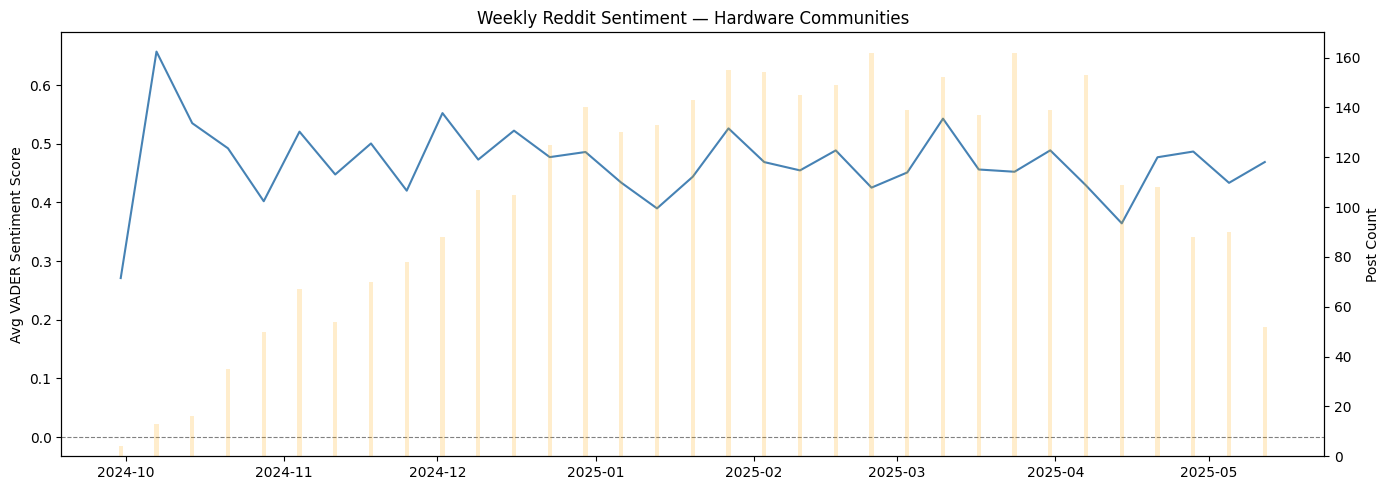

In [8]:
all_weekly = sentiment_weekly[sentiment_weekly["subreddit"] == "ALL"].copy()
all_weekly["week_dt"] = all_weekly["week"].dt.to_timestamp()
all_weekly = all_weekly.sort_values("week_dt")
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(all_weekly["week_dt"], all_weekly["avg_sentiment"],color="steelblue",label="Avg Sentiment")
ax1.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax1.set_ylabel("Avg VADER Sentiment Score")
ax1.set_title("Weekly Reddit Sentiment — Hardware Communities")
ax2 = ax1.twinx()
ax2.bar(all_weekly["week_dt"], all_weekly["post_count"], alpha=0.2, color="orange", label="Post Count")
ax2.set_ylabel("Post Count")
plt.tight_layout()
plt.savefig("../data/processed/sentiment_timeline.png", dpi=150)
plt.show()